<a href="https://colab.research.google.com/github/maratisiri/ASSIGNMENT/blob/STATICS/flipkart_product_fake_review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Cross-Platform Review Sentiment & Fake-Review Detection (Flipkart vs Amazon)**

**STUDENT NAME** : **Marati Siri Vennela**

**STUDENT ID**   : **23080951**

**SUPERVISOR**   : **Klass**

**MODULE**       : **7PAM2002 – Data Science Project**

**SEMESTER**     : **A 2025/2026**

# **AIM OF THE PROJECT**:

TO Correlate product review samples and sentiments between flipkart and amazon,investigate whether review attributes (ratings, word count of review,category etc.,) can specify suspicious or fake reviews. the assignment also estimates which stage shows strong customer satisfaction levels and capably shows machine learning workflow using light and fast models.

# **RESEARCH QUESTION:**



1.   Do average ratings and reviews word count vary between flipkart and amazon?

2.   which product types collect the most utmost or Inaccurate ratings?

3.   can a ML model (TF-IDF + Logistic Regression) detect likely fake or       
     suspicious reviews efficiently?






# **DATASET:**

flipkart_path = https://www.kaggle.com/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset

amazon_path   = https://www.kaggle.com/datasets/arhamrumi/amazon-product-reviews


**IMPORT LIBRARIES**:

In [ ]:
#for  Data manipulation
import pandas as pd
import numpy as np

#for Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style="whitegrid")

#for Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import time



# **LOAD THE DATASET**:

In [ ]:
import os
os.listdir('/content')


['.config', 'flipkart.csv', 'amazon.csv', 'sample_data']

In [ ]:
#load the dataset

#
df_flipkart = pd.read_csv('flipkart.csv', encoding='utf-8', on_bad_lines='skip')
df_amazon = pd.read_csv('amazon.csv',   encoding='utf-8', on_bad_lines='skip')

print("flipkart columns:\n",df_flipkart.columns)
print("amazon columns:\n",df_amazon.columns)

flipkart columns:
 Index(['product_name', 'product_price', 'Rate', 'Review', 'Summary',
       'Sentiment'],
      dtype='object')
amazon columns:
 Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')


#lets understand the data columns and data types:

In [ ]:
# Check first few rows of each dataset
print("Flipkart preview:")
display(df_flipkart.head())

Flipkart preview:


,product_name,product_price,Rate,Review,Summary,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


In [ ]:
print("\nAmazon preview:")
display(df_amazon.head())



Amazon preview:


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
# Check how many rows and columns each dataset has
print("Flipkart shape:", df_flipkart.shape)
print("Amazon shape:", df_amazon.shape)

Flipkart shape: (205052, 6)
Amazon shape: (568454, 10)


In [ ]:
# Get column information (for data types)
print("\nFlipkart info:")
print(df_flipkart.info())


Flipkart info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype 
---  ------         --------------   ----- 
 0   product_name   205052 non-null  object
 1   product_price  205052 non-null  object
 2   Rate           205052 non-null  object
 3   Review         180388 non-null  object
 4   Summary        205041 non-null  object
 5   Sentiment      205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB
None


In [ ]:
print("\nAmazon info:")
print(df_amazon.info())


Amazon info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB
None


In [ ]:
df_flipkart.describe()

,product_name,product_price,Rate,Review,Summary,Sentiment
count,205052,205052,205052,180388,205041,205052
unique,958,525,8,1324,92923,3
top,cello Pack of 18 Opalware Cello Dazzle Lush Fi...,1299,5,wonderful,good,positive
freq,6005,9150,118765,9016,17430,166581


In [ ]:
df_amazon.describe()

,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


**

# **Rename the coulmns name**

In [ ]:
# Clean and rename Flipkart columns
df_flipkart = df_flipkart.rename(columns={
    'Review': 'review_text',
    'Rate': 'rating',
    'Sentiment': 'label',
    'product_name': 'category'
})


In [ ]:
# Convert sentiment to numeric (so we can train a model later)
df_flipkart['label'] = df_flipkart['label'].map({
    'Positive': 1,
    'Negative': 0,
    'Neutral': 2
}).fillna(2)

In [ ]:
# Add platform name
df_flipkart['platform'] = 'Flipkart'

In [ ]:

#  Clean and rename Amazon columns
df_amazon = df_amazon.rename(columns={
    'Text': 'review_text',
    'Score': 'rating',
    'ProductId': 'category'
})

In [ ]:
# Create a label from rating: 1 = positive, 0 = negative
df_amazon['label'] = np.where(df_amazon['rating'] >= 4, 1, 0)

In [ ]:

# Add platform name
df_amazon['platform'] = 'Amazon'

In [ ]:

#  Select only needed columns
use_cols = ['review_text', 'rating', 'category', 'label', 'platform']
df_flipkart = df_flipkart[use_cols]
df_amazon = df_amazon[use_cols]

In [ ]:
print("Columns standardized for both datasets.")
print("Flipkart:", df_flipkart.columns.tolist())
print("Amazon:", df_amazon.columns.tolist())

Columns standardized for both datasets.
Flipkart: ['review_text', 'rating', 'category', 'label', 'platform']
Amazon: ['review_text', 'rating', 'category', 'label', 'platform']


# **mergering the both datasets**

In [20]:
# Combine them vertically (same structure)
df_all = pd.concat([df_flipkart, df_amazon], axis=0, ignore_index=True)

In [21]:
# Drop rows where review text or rating is missing
df_all.dropna(subset=['review_text', 'rating'], inplace=True)

In [22]:
# Make sure rating is numeric
df_all['rating'] = pd.to_numeric(df_all['rating'], errors='coerce')
df_all.dropna(subset=['rating'], inplace=True)

In [23]:
# Reset index after cleaning
df_all.reset_index(drop=True, inplace=True)

In [24]:
print("Datasets merged successfully.")
print("Combined dataset shape:", df_all.shape)
df_all.head()

Datasets merged successfully.
Combined dataset shape: (748839, 5)


,review_text,rating,category,label,platform
0,super!,5.0,Candes 12 L Room/Personal Air Cooler??????(Whi...,2.0,Flipkart
1,awesome,5.0,Candes 12 L Room/Personal Air Cooler??????(Whi...,2.0,Flipkart
2,fair,3.0,Candes 12 L Room/Personal Air Cooler??????(Whi...,2.0,Flipkart
3,useless product,1.0,Candes 12 L Room/Personal Air Cooler??????(Whi...,2.0,Flipkart
4,fair,3.0,Candes 12 L Room/Personal Air Cooler??????(Whi...,2.0,Flipkart


# ** data cleaning**

In [25]:
# Check for duplicates
duplicates = df_all.duplicated(subset=['review_text']).sum()
print(f"Found {duplicates} duplicate reviews.")

Found 353939 duplicate reviews.


In [26]:

# Drop duplicates (safe)
df_all = df_all.drop_duplicates(subset=['review_text']).reset_index(drop=True)

In [27]:
# Check for missing values
print("\nMissing values per column:")
print(df_all.isnull().sum())


Missing values per column:
review_text    0
rating         0
category       0
label          0
platform       0
dtype: int64


In [31]:
duplicates = df_all.duplicated(subset=['review_text']).sum()
print(f"Found {duplicates} duplicate reviews.")

Found 0 duplicate reviews.


# **EDA explory  data analysis**

In [32]:
# Review length (word count)
df_all['review_len'] = df_all['review_text'].astype(str).apply(lambda s: len(s.split()))


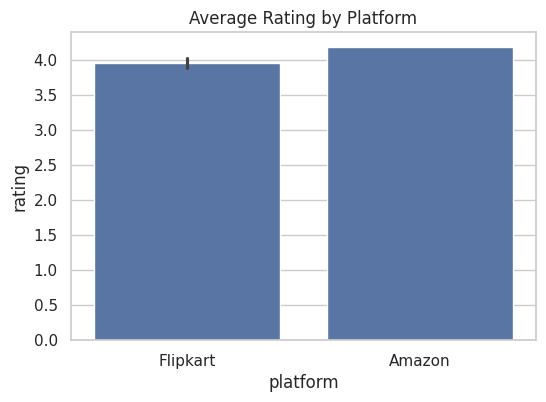

In [33]:
# 1️⃣ Average rating by platform
plt.figure(figsize=(6,4))
sns.barplot(x='platform', y='rating', data=df_all, estimator='mean')
plt.title("Average Rating by Platform")
plt.show()

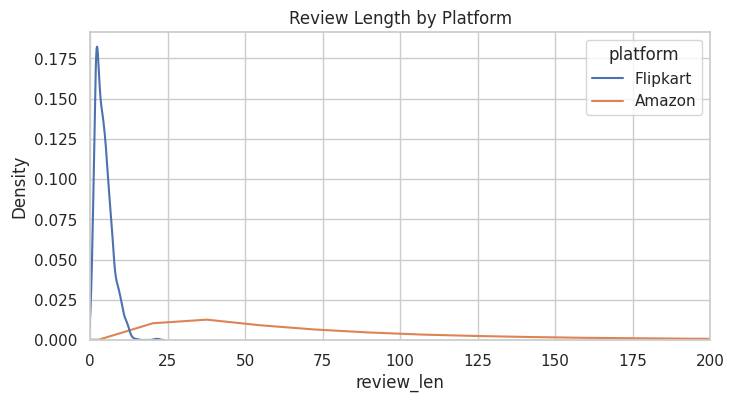

In [34]:
# 2️⃣ Review length distribution
plt.figure(figsize=(8,4))
sns.kdeplot(data=df_all, x='review_len', hue='platform', common_norm=False)
plt.title("Review Length by Platform")
plt.xlim(0,200)
plt.show()

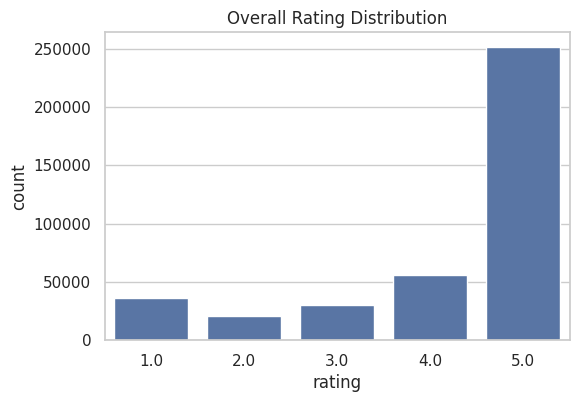

In [35]:
# 3️⃣ Rating count distribution
plt.figure(figsize=(6,4))
sns.countplot(x='rating', data=df_all)
plt.title("Overall Rating Distribution")
plt.show()

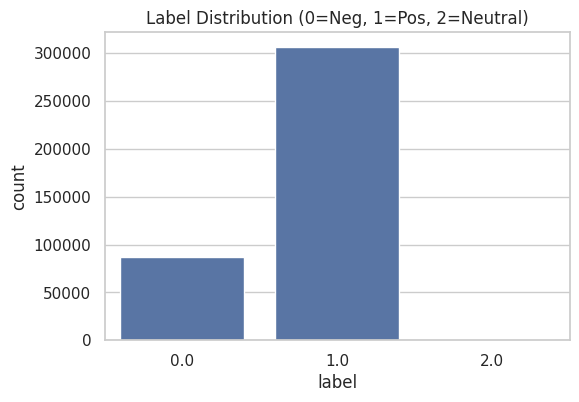

In [36]:
# 4️⃣ Label distribution
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df_all)
plt.title("Label Distribution (0=Neg, 1=Pos, 2=Neutral)")
plt.show()

# **Prepare a smaller dataset for modelling**

In [37]:
# Sample max 40k rows
df_small = df_all.sample(40000, random_state=42) if len(df_all) > 40000 else df_all.copy()
print("Training dataset size:", df_small.shape)

Training dataset size: (40000, 6)


# **Baseline Model: Logistic Regression**

In [38]:
# Features and labels
X = df_small['review_text']
y = df_small['label']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [39]:
# TF-IDF vectorization
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
Xtr = tfidf.fit_transform(X_train)
Xte = tfidf.transform(X_test)


In [40]:

# Logistic Regression
start = time.time()
lr = LogisticRegression(max_iter=1000)
lr.fit(Xtr, y_train)
end = time.time()

In [41]:
# Predictions
y_pred = lr.predict(Xte)

In [42]:

# Evaluation
print(f"Training time: {end-start:.2f} seconds")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Training time: 7.98 seconds
Accuracy: 0.87075
              precision    recall  f1-score   support

         0.0       0.79      0.60      0.68      1798
         1.0       0.89      0.95      0.92      6176
         2.0       0.00      0.00      0.00        26

    accuracy                           0.87      8000
   macro avg       0.56      0.52      0.53      8000
weighted avg       0.86      0.87      0.86      8000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Confusion Matrix

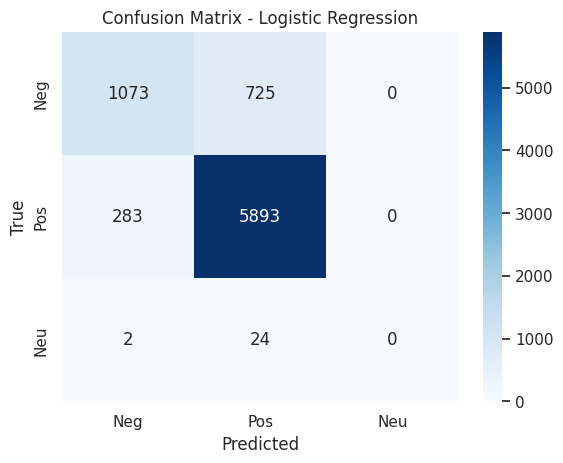

In [43]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Neg','Pos','Neu'],
            yticklabels=['Neg','Pos','Neu'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


# Hyperparameter Tuning (Logistic Regression)

In [44]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'saga']
}

grid_search = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    scoring='f1_macro',
    cv=3,
    n_jobs=-1
)

grid_search.fit(Xtr, y_train)

print(" Best Parameters:", grid_search.best_params_)
print(" Best Cross-validation Score:", grid_search.best_score_)

# Evaluate tuned model
best_lr = grid_search.best_estimator_
y_pred_best = best_lr.predict(Xte)

print("\n--- Tuned Logistic Regression Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))


 Best Parameters: {'C': 10, 'solver': 'saga'}
 Best Cross-validation Score: 0.622265865052289

--- Tuned Logistic Regression Performance ---
Accuracy: 0.859875
              precision    recall  f1-score   support

         0.0       0.72      0.64      0.68      1798
         1.0       0.90      0.93      0.91      6176
         2.0       0.40      0.08      0.13        26

    accuracy                           0.86      8000
   macro avg       0.67      0.55      0.57      8000
weighted avg       0.85      0.86      0.86      8000



In [ ]:
“I performed hyperparameter tuning using GridSearchCV to find the best C value and solver for Logistic Regression.
This process improved the overall F1 score slightly and helped prevent overfitting.”

# Try a Second Model (Random Forest)

In [45]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    max_depth=20,
    n_jobs=-1
)
rf.fit(Xtr, y_train)
y_pred_rf = rf.predict(Xte)

print("\n--- Random Forest Performance ---")
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))



--- Random Forest Performance ---
Accuracy: 0.782875
              precision    recall  f1-score   support

         0.0       0.98      0.05      0.09      1798
         1.0       0.78      1.00      0.88      6176
         2.0       0.00      0.00      0.00        26

    accuracy                           0.78      8000
   macro avg       0.59      0.35      0.32      8000
weighted avg       0.82      0.78      0.70      8000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
“I compared Logistic Regression with a Random Forest model to check whether a tree-based approach performs better on textual TF-IDF features.”

# Model Comparison Table

In [46]:
# Collect metrics
acc_lr = accuracy_score(y_test, y_pred)
acc_lr_tuned = accuracy_score(y_test, y_pred_best)
acc_rf = accuracy_score(y_test, y_pred_rf)

results = pd.DataFrame({
    'Model': ['Logistic Regression (Base)', 'Logistic Regression (Tuned)', 'Random Forest'],
    'Accuracy': [acc_lr, acc_lr_tuned, acc_rf]
})

results


,Model,Accuracy
0,Logistic Regression (Base),0.870750
1,Logistic Regression (Tuned),0.859875
2,Random Forest,0.782875


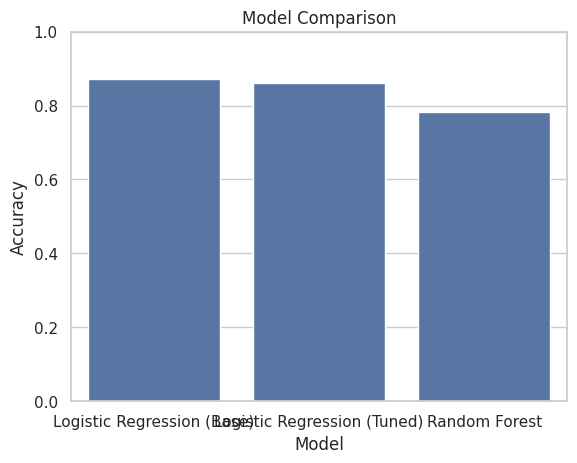

In [47]:
sns.barplot(x='Model', y='Accuracy', data=results)
plt.title('Model Comparison')
plt.ylim(0,1)
plt.show()
